In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import random
import numpy as np
import torch

def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


set_seed(42)

In [3]:
import os
import pandas as pd

data_dir = '/content/drive/MyDrive/FundamentofDS/processed/multi'

X = np.load(os.path.join(data_dir, 'X_multi.npy'))
y = np.load(os.path.join(data_dir, 'y_multi.npy'))

df_meta = pd.read_csv(os.path.join(data_dir, 'metadata_multi.csv'))

train_mask = df_meta['strat_fold'] <= 8
val_mask   = df_meta['strat_fold'] == 9
test_mask  = df_meta['strat_fold'] == 10

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val     = X[val_mask], y[val_mask]
X_test, y_test   = X[test_mask], y[test_mask]

total = len(df_meta)
print(f"Train: {len(X_train)} samples ({len(X_train)/total*100:.1f}%)")
print(f"Val:   {len(X_val)} samples ({len(X_val)/total*100:.1f}%)")
print(f"Test:  {len(X_test)} samples ({len(X_test)/total*100:.1f}%)")

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Unique y_train labels: {np.unique(y_train)}")

Train: 17418 samples (79.9%)
Val:   2183 samples (10.0%)
Test:  2198 samples (10.1%)
X_train shape: (17418, 1000, 12), y_train shape: (17418, 5)
Unique y_train labels: [0 1]


In [4]:
np.save(os.path.join(data_dir, 'X_train (1).npy'), X_train)
np.save(os.path.join(data_dir, 'y_train (1).npy'), y_train)

np.save(os.path.join(data_dir, 'X_val.npy (1)'), X_val)
np.save(os.path.join(data_dir, 'y_val.npy (1)'), y_val)

np.save(os.path.join(data_dir, 'X_test (1).npy'), X_test)
np.save(os.path.join(data_dir, 'y_test (1).npy'), y_test)

In [5]:
X_train = np.transpose(X_train, (0, 2, 1))
X_val   = np.transpose(X_val, (0, 2, 1))
X_test  = np.transpose(X_test, (0, 2, 1))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17418, 12, 1000)
X_val shape: (2183, 12, 1000)
X_test shape: (2198, 12, 1000)


In [6]:
!git clone https://github.com/hsd1503/resnet1d.git

fatal: destination path 'resnet1d' already exists and is not an empty directory.


In [7]:
import sys
sys.path.append('/content/resnet1d')

from resnet1d.resnet1d import ResNet1D

In [8]:
print(ResNet1D)

<class 'resnet1d.resnet1d.ResNet1D'>


In [9]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.float32)

num_samples, in_channels, seq_len = X_train_tensor.shape
print(f"Dataset summary: {num_samples} samples | {in_channels} channels | {seq_len} sequence length")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader    = DataLoader(val_dataset, batch_size=32, shuffle=False)

Dataset summary: 17418 samples | 12 channels | 1000 sequence length


In [11]:
num_classes = y_train.shape[1]
print(f"Number of classes: {num_classes}")

Number of classes: 5


In [12]:
model = ResNet1D(
    in_channels=12,
    base_filters=64,
    kernel_size=16,
    stride=2,
    groups=1,
    n_classes=num_classes,
    n_block=4
).to(device)

In [13]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

In [14]:
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):

  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device).float()

    optimizer.zero_grad()

    outputs = model(inputs)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)

    preds = (outputs >= 0.0).float()

    correct += (preds == labels).sum().item()

    total += labels.numel()

  train_loss = running_loss / len(train_loader.dataset)
  train_acc = (correct / total) * 100

  model.eval()
  val_loss = 0.0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device).float()

      outputs = model(inputs)
      loss = criterion(outputs, labels)

      val_loss += loss.item() * inputs.size(0)

      preds = (outputs >= 0.0).float()
      val_correct += (preds == labels).sum().item()
      val_total += labels.numel()

  val_loss = val_loss / len(val_loader.dataset)
  val_acc = (val_correct / val_total) * 100

  scheduler.step(val_loss)

  print(
      f"Epoch [{epoch+1:02d}/{num_epochs}] | "
      f"Train Loss: {train_loss:.4f} | Train Element-Acc: {train_acc:.2f}% | "
      f"Val Loss: {val_loss:.4f} | Val Element-Acc: {val_acc:.2f}%"
  )

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(model.state_dict(), 'best_resnet1d_multilabel.pth')
    print(f"   --> Saved new best model with Val Loss: {val_loss:.4f}")

print(f"\nTraining completed! Best Val Loss achieved: {best_val_loss:.4f}")

Epoch [01/15] | Train Loss: 0.3621 | Train Element-Acc: 84.65% | Val Loss: 0.3478 | Val Element-Acc: 84.84%
   --> Saved new best model with Val Loss: 0.3478
Epoch [02/15] | Train Loss: 0.3203 | Train Element-Acc: 86.50% | Val Loss: 0.3257 | Val Element-Acc: 86.14%
   --> Saved new best model with Val Loss: 0.3257
Epoch [03/15] | Train Loss: 0.3045 | Train Element-Acc: 87.32% | Val Loss: 0.3375 | Val Element-Acc: 86.07%
Epoch [04/15] | Train Loss: 0.2957 | Train Element-Acc: 87.71% | Val Loss: 0.3094 | Val Element-Acc: 86.73%
   --> Saved new best model with Val Loss: 0.3094
Epoch [05/15] | Train Loss: 0.2884 | Train Element-Acc: 87.91% | Val Loss: 0.3098 | Val Element-Acc: 87.30%
Epoch [06/15] | Train Loss: 0.2839 | Train Element-Acc: 88.30% | Val Loss: 0.3027 | Val Element-Acc: 87.13%
   --> Saved new best model with Val Loss: 0.3027
Epoch [07/15] | Train Loss: 0.2796 | Train Element-Acc: 88.30% | Val Loss: 0.3143 | Val Element-Acc: 87.12%
Epoch [08/15] | Train Loss: 0.2758 | Train E

In [15]:
!git clone https://github.com/liguge/1D-Grad-CAM-for-interpretable-intelligent-fault-diagnosis.git

fatal: destination path '1D-Grad-CAM-for-interpretable-intelligent-fault-diagnosis' already exists and is not an empty directory.


In [24]:
import matplotlib.pyplot as plt

%matplotlib inline

sys.path.append('./1D-Grad-CAM-for-interpretable-intelligent-fault-diagnosis')

LABEL_NAMES = {
    0: "Normal",
    1: "AFIB",
    2: "GSVT",
    3: "SB",
    4: "ST",
}

def get_1d_gradcam(model, input_tensor, target_layer, target_class_idx=None):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, input, output):
        activations.append(output)

    h_f = target_layer.register_forward_hook(forward_hook)
    h_b = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    output = model(input_tensor)

    if output.ndim > 1:
        output = output.squeeze(0)

    if target_class_idx is None:
        target_class_idx = torch.argmax(output).item()

    score = output[target_class_idx]
    score.backward(retain_graph=True)

    h_f.remove()
    h_b.remove()

    grads = gradients[0]
    acts = activations[0]

    weights = torch.mean(grads, dim=-1, keepdim=True)

    cam = torch.sum(weights * acts, dim=1, keepdim=True)
    cam = torch.relu(cam)

    cam = torch.nn.functional.interpolate(
        cam,
        size=input_tensor.shape[-1],
        mode='linear',
        align_corners=False
    )

    cam_mask = cam.squeeze().cpu().detach().numpy()

    if cam_mask.max() != 0:
        cam_mask = cam_mask / cam_mask.max()

    return cam_mask

In [26]:
def predict_and_explain(label_vector):
  names = [
      LABEL_NAMES[i] for i, val in enumerate(label_vector) if val == 1
  ]
  if "NORM" in names:
    return ["Normal (NORM)"]
  return names if names else ["Normal (NORM)"]

def predict_and_explain(
    patient_idx,
    X_data,
    y_data,
    model,
    target_layer,
    target_class_idx=None,
    device="cuda",
):
  model.eval()

  sample_ecg = X_data[patient_idx : patient_idx + 1]

  true_label = y_data[patient_idx]
  if isinstance(true_label, torch.Tensor):
    true_label = true_label.cpu().numpy()
  true_label = np.array(true_label, dtype=np.float32)

  input_tensor = torch.tensor(sample_ecg, dtype=torch.float32).to(device)

  with torch.no_grad():
    output = model(input_tensor)
    probs = torch.sigmoid(output).squeeze(0).cpu().numpy()

  pred_labels = (probs >= 0.5).astype(int)

  true_diseases = [
      LABEL_NAMES[i] for i, val in enumerate(true_label) if val == 1
  ]
  pred_diseases = [
      LABEL_NAMES[i] for i, val in enumerate(pred_labels) if val == 1
  ]

  if target_class_idx is None:
    target_class_idx = int(np.argmax(probs))

  target_class_name = LABEL_NAMES[target_class_idx]

  cam_mask = get_1d_gradcam(
      model, input_tensor, target_layer, target_class_idx
  )

  return {
      "idx": patient_idx,
      "input_tensor": input_tensor,
      "true_label": true_label,
      "pred_label": pred_labels,
      "true_diseases": true_diseases if true_diseases else ["NORM"],
      "pred_diseases": pred_diseases if pred_diseases else ["NORM"],
      "probs": probs,
      "cam_mask": cam_mask,
      "explained_class": target_class_name,
  }

In [29]:
def plot_ecg_gradcam(res, lead_idx=1, lead_name="Lead II"):
    signal = res['input_tensor'][0, lead_idx].cpu().numpy()

    true_str = ", ".join(res['true_diseases']) if 'true_diseases' in res else ", ".join([LABEL_NAMES[i] for i in res['true_label']])
    pred_str = ", ".join(res['pred_diseases']) if 'pred_diseases' in res else ", ".join([LABEL_NAMES[i] for i in res['pred_label']])

    print(f"Ground Truth : {true_str}")
    print(f"Prediction   : {pred_str}")

    if 'probs' in res:
        print("\nClass Probabilities:")
        for i, name in LABEL_NAMES.items():
            print(f"  {name:5s}: {res['probs'][i] * 100:6.2f}%")

    plt.figure(figsize=(14, 4))
    time_steps = np.arange(len(signal))

    plt.plot(time_steps, signal, color="black", linewidth=1.2, label=lead_name)

    plt.scatter(
        time_steps,
        signal,
        c=res['cam_mask'],
        cmap="jet",
        s=10,
        alpha=0.8,
        zorder=3,
        label=f"Grad-CAM ({res['explained_class']})"
    )

    plt.colorbar(label="Grad-CAM Importance")
    plt.title(f"ECG Grad-CAM Explanation | Lead: {lead_name} | Class: {res['explained_class']}")
    plt.xlabel("Time Steps")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

True diseases: ['NORM']
Predicted diseases: ['NORM']
Grad-CAM explaining class: NORM
Ground Truth : NORM
Prediction   : NORM

Class Probabilities:
  CD   :   0.14%
  HYP  :   5.01%
  MI   :   1.96%
  NORM :  98.08%
  STTC :  11.91%


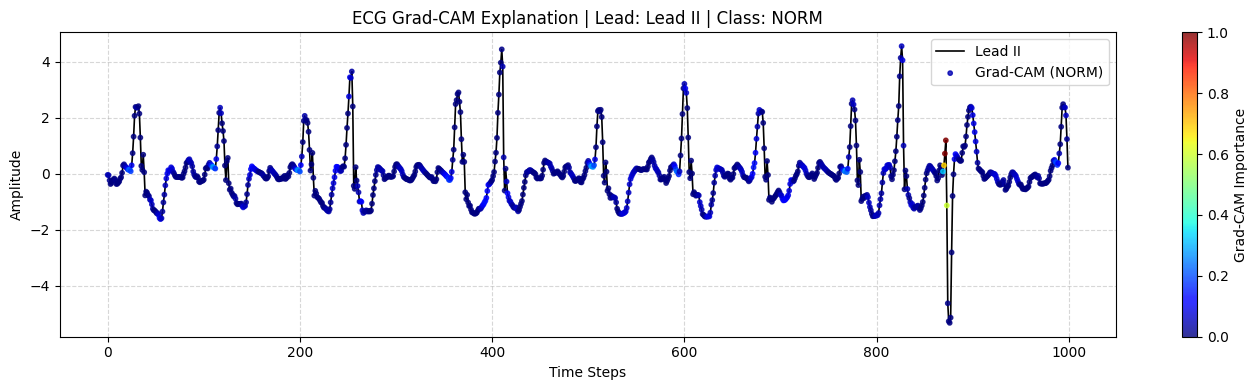

In [31]:
target_layer = model.first_block_conv
random_idx = np.random.randint(0, len(X_test))

results = predict_and_explain(
    patient_idx=random_idx,
    X_data=X_test,
    y_data=y_test,
    model=model,
    target_layer=target_layer,
    device=device,
)

print(f"True diseases: {results['true_diseases']}")
print(f"Predicted diseases: {results['pred_diseases']}")
print(f"Grad-CAM explaining class: {results['explained_class']}")

plot_ecg_gradcam(results, lead_idx=1, lead_name="Lead II")

In [32]:
from sklearn.metrics import classification_report
import torch


def get_classification_report(
    model, X_test, y_test, device='cuda', threshold=0.5
):
  model.eval()

  inputs = torch.tensor(X_test, dtype=torch.float32).to(device)

  with torch.no_grad():
    outputs = model(inputs)
    probs = torch.sigmoid(outputs).cpu().numpy()

  preds = (probs >= threshold).astype(int)
  y_true = y_test.astype(int)

  print(" CLASSIFICATION REPORT ".center(60, "="))
  print(
      classification_report(
          y_true,
          preds,
          target_names=[
              'CD (Conduction Disturbance)',
              'HYP (Hypertrophy)',
              'MI (Myocardial Infarction)',
              'NORM (Normal)',
              'STTC (ST/T Change)',
          ],
          digits=4,
          zero_division=0,
      )
  )

  return y_true, preds, probs


y_true, preds, probs = get_classification_report(
    model, X_test, y_test, device=device
)

================== CLASSIFICATION REPORT ===================
                             precision    recall  f1-score   support

CD (Conduction Disturbance)     0.7770    0.9263    0.8451       963
          HYP (Hypertrophy)     0.8057    0.5655    0.6645       550
 MI (Myocardial Infarction)     0.7754    0.7095    0.7410       506
              NORM (Normal)     0.7344    0.7359    0.7351       496
         STTC (ST/T Change)     0.6047    0.2977    0.3990       262

                  micro avg     0.7644    0.7220    0.7426      2777
                  macro avg     0.7394    0.6470    0.6769      2777
               weighted avg     0.7585    0.7220    0.7286      2777
                samples avg     0.7436    0.7343    0.7239      2777



Macro ROC-AUC Score : 0.9051

Class CD    | Specificity:  79.27%
Class HYP   | Specificity:  95.45%
Class MI    | Specificity:  93.85%
Class NORM  | Specificity:  92.24%
Class STTC  | Specificity:  97.37%


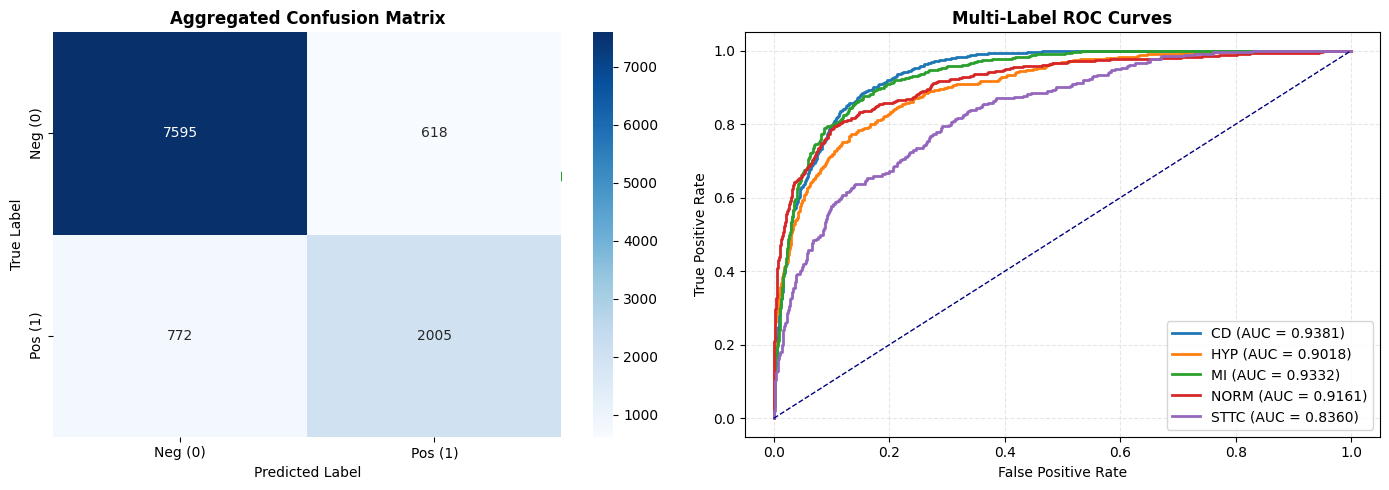

In [34]:
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix, roc_auc_score, roc_curve

def plot_extended_metrics_and_plots(y_true, preds, probs):
  macro_auc = roc_auc_score(y_true, probs, average="macro")
  print(f"Macro ROC-AUC Score : {macro_auc:.4f}\n")

  mcm = multilabel_confusion_matrix(y_true, preds)
  num_classes = y_true.shape[1]

  for i in range(num_classes):
    tn, fp, fn, tp = mcm[i].ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(
        f"Class {LABEL_NAMES.get(i, i):<5} | Specificity: {spec * 100:6.2f}%"
    )

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  for i in range(num_classes):
    tn, fp, fn, tp = mcm[i].ravel()
    axes[0].scatter(
        i,
        tp / (tp + fn) if (tp + fn) > 0 else 0,
        label=f"{LABEL_NAMES.get(i, i)}",
    )

  sns.heatmap(
      mcm.sum(axis=0),
      annot=True,
      fmt="d",
      cmap="Blues",
      ax=axes[0],
      xticklabels=["Neg (0)", "Pos (1)"],
      yticklabels=["Neg (0)", "Pos (1)"],
  )
  axes[0].set_title(
      "Aggregated Confusion Matrix", fontsize=12, fontweight="bold"
  )
  axes[0].set_xlabel("Predicted Label")
  axes[0].set_ylabel("True Label")

  for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
    class_auc = roc_auc_score(y_true[:, i], probs[:, i])
    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"{LABEL_NAMES.get(i, i)} (AUC = {class_auc:.4f})",
    )

  axes[1].plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
  axes[1].set_title("Multi-Label ROC Curves", fontsize=12, fontweight="bold")
  axes[1].set_xlabel("False Positive Rate")
  axes[1].set_ylabel("True Positive Rate")
  axes[1].legend(loc="lower right")
  axes[1].grid(True, linestyle="--", alpha=0.3)

  plt.tight_layout()
  plt.show()


plot_extended_metrics_and_plots(y_true, preds, probs)

In [35]:
def extract_gradcam_sample_indices(y_true, preds, target_class_idx=0):
  y_true_cls = y_true[:, target_class_idx]
  preds_cls = preds[:, target_class_idx]

  fn_indices = np.where((y_true_cls == 1) & (preds_cls == 0))[0]
  fp_indices = np.where((y_true_cls == 0) & (preds_cls == 1))[0]
  tp_indices = np.where((y_true_cls == 1) & (preds_cls == 1))[0]

  class_name = LABEL_NAMES.get(target_class_idx, target_class_idx)

  print(f" GRAD-CAM INDICES FOR CLASS: {class_name} ".center(60, "="))
  print(f"- False Negative Indices : {list(fn_indices[:5])}")
  print(f"- True Positive Indices  : {list(tp_indices[:5])}")
  print(f"- False Positive Indices : {list(fp_indices[:5])}")

  return fn_indices, tp_indices, fp_indices


fn_idx, tp_idx, fp_idx = extract_gradcam_sample_indices(
    y_true, preds, target_class_idx=2
)

============== GRAD-CAM INDICES FOR CLASS: MI ==============
- False Negative Indices : [np.int64(14), np.int64(23), np.int64(53), np.int64(75), np.int64(88)]
- True Positive Indices  : [np.int64(19), np.int64(24), np.int64(25), np.int64(39), np.int64(40)]
- False Positive Indices : [np.int64(37), np.int64(67), np.int64(70), np.int64(84), np.int64(99)]


In [36]:
import shutil

shutil.copy(
    'best_resnet1d_model.pth',
    '/content/drive/MyDrive/FundamentofDS/processed/resnet1d_multilabel.pt',
)

'/content/drive/MyDrive/FundamentofDS/processed/resnet1d_multilabel.pt'